In [1]:
import pandas as pd
from tqdm import tqdm
from utils import Optimizer, enhance, Pipeline, get_importance_score, MeanEncoder, SelectColumns

import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

In [2]:
data = pd.read_csv("./data/train.csv", index_col=0)

to_lag = ["forward_returns", "risk_free_rate", "market_forward_excess_returns"]
to_drop = ["E7", "V10", "S3", "M1", "M13", "M14", "M6", "V9"]
for i in range(1, 10):
    data[f"D{i}"] = data[f"D{i}"] != 0
    data[f"D{i}"] = data[f"D{i}"].astype("category")

for i in to_lag:
    data[f"lag_{i}"] = data[i].shift(1)

data["target"] = (data["forward_returns"] - data["risk_free_rate"]) > 0
data

,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,...,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns,lag_forward_returns,lag_risk_free_rate,lag_market_forward_excess_returns,target
date_id,,,,,,,,,,,,,,,,,,,,,
0,False,False,False,True,True,False,False,False,True,NaN,...,NaN,NaN,NaN,-0.002421,0.000301,-0.003038,NaN,NaN,NaN,False
1,False,False,False,True,True,False,False,False,True,NaN,...,NaN,NaN,NaN,-0.008495,0.000303,-0.009114,-0.002421,0.000301,-0.003038,False
2,False,False,False,True,False,False,False,False,True,NaN,...,NaN,NaN,NaN,-0.009624,0.000301,-0.010243,-0.008495,0.000303,-0.009114,False
3,False,False,False,True,False,False,False,False,False,NaN,...,NaN,NaN,NaN,0.004662,0.000299,0.004046,-0.009624,0.000301,-0.010243,True
4,False,False,False,True,False,False,False,False,False,NaN,...,NaN,NaN,NaN,-0.011686,0.000299,-0.012301,0.004662,0.000299,0.004046,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9016,False,False,False,True,False,False,False,False,False,1.493117,...,-0.327455,0.083995,-0.380452,-0.000015,0.000151,-0.000477,0.010401,0.000152,0.009936,False
9017,False,False,False,True,False,False,False,False,False,1.490889,...,-0.372979,0.094246,-0.427355,-0.005199,0.000150,-0.005661,-0.000015,0.000151,-0.000477,False
9018,False,False,False,True,False,True,False,False,False,1.488667,...,-0.282024,0.090608,-0.381337,0.005930,0.000150,0.005467,-0.005199,0.000150,-0.005661,True


计算Importance
计算Null Importance


100%|██████████| 96/96 [01:01<00:00,  1.55it/s]


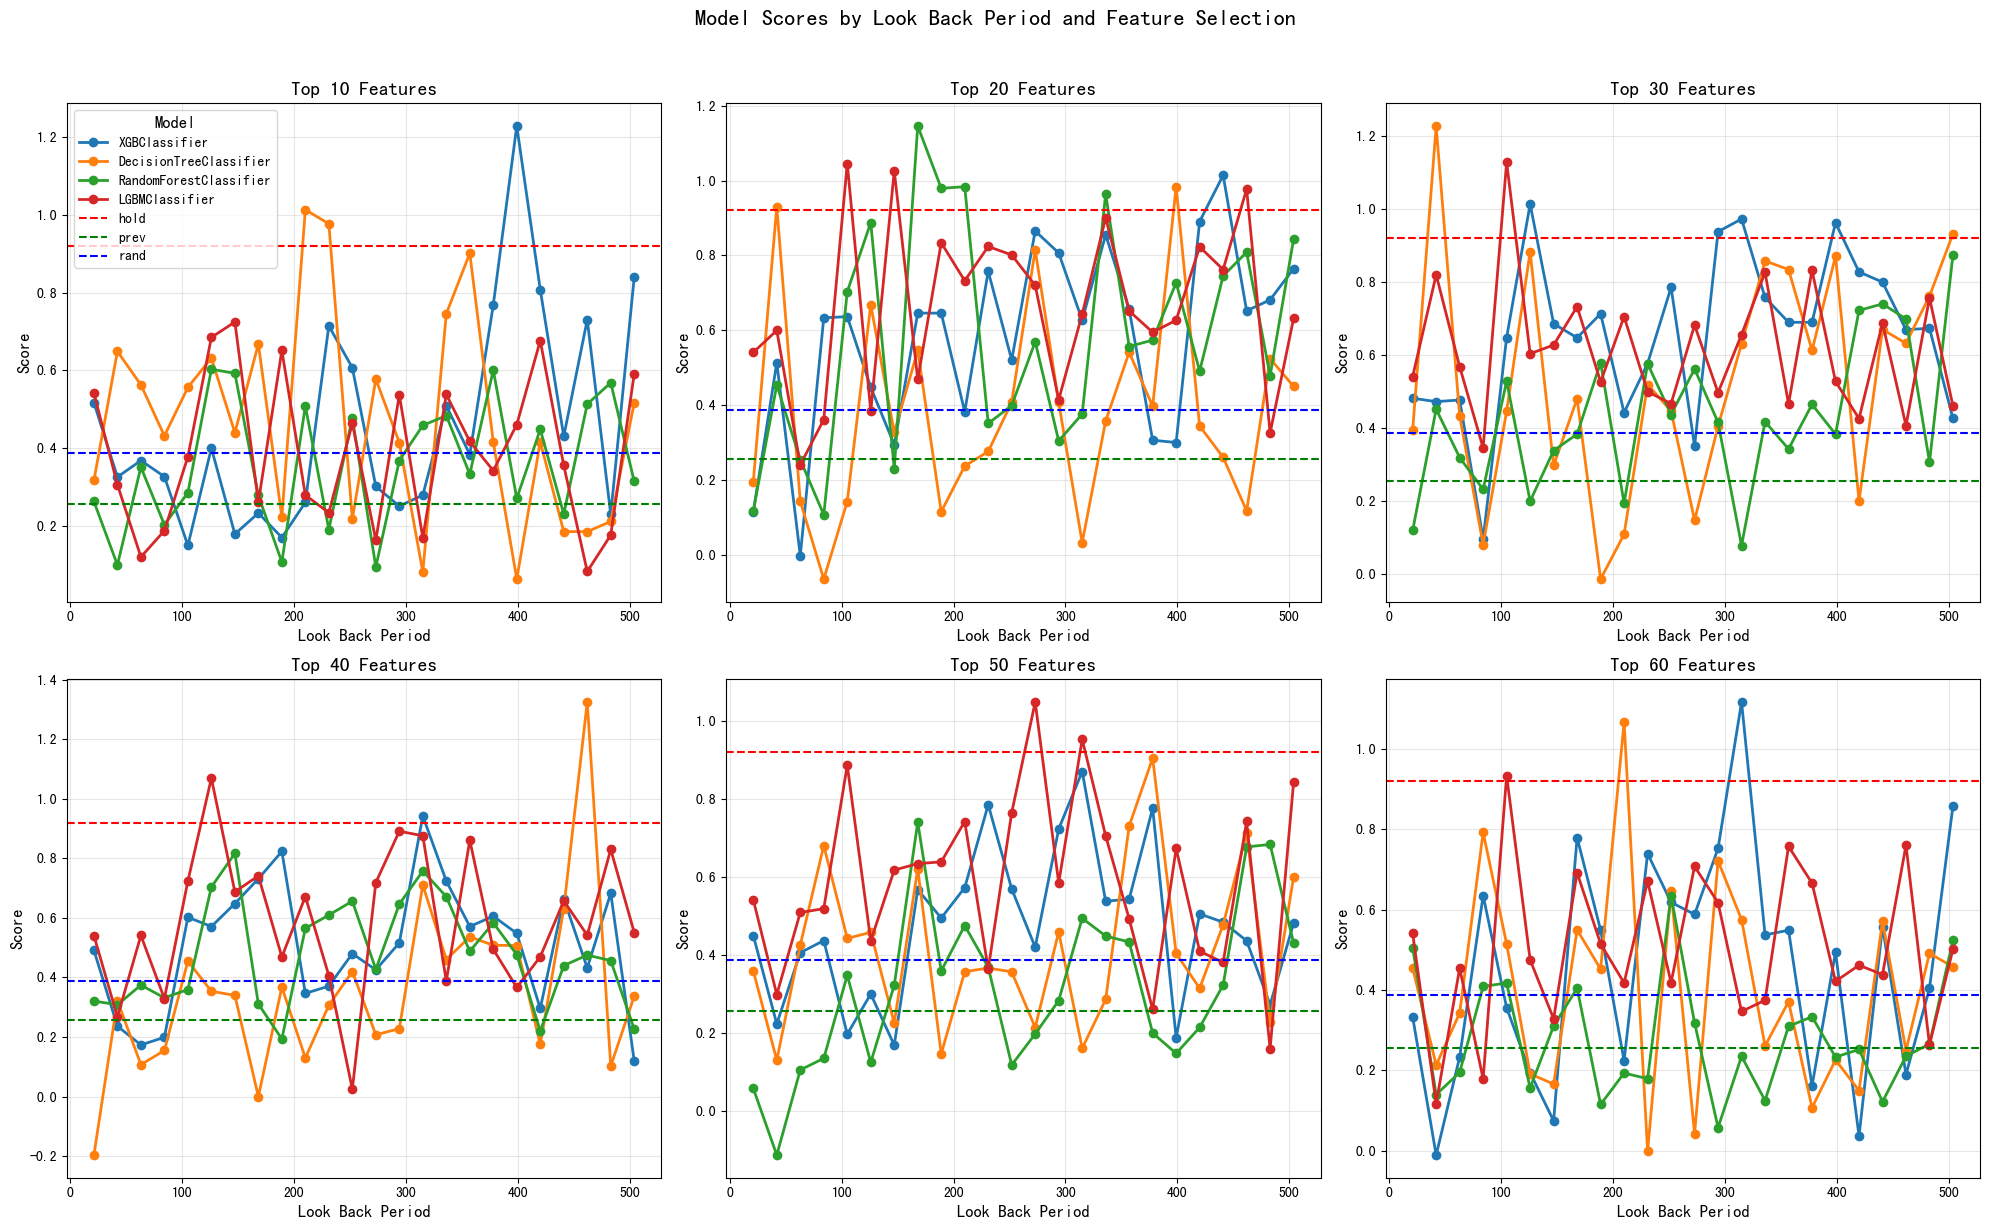

In [4]:
"""
不构造额外特征，测试不同模型和不同窗口下的策略表现
模型平均表现和随机策略差不多
"""

opt = Optimizer(
    dataset=data,
    primitives=[],  #不构造特征
    drop_columns=to_drop + to_lag,
)
baseline = opt.baseline()
score_df, _, _ = get_importance_score(opt.x, opt.y)
opt.model_clz_list = [
    XGBClassifier,
    DecisionTreeClassifier,
    RandomForestClassifier,
    LGBMClassifier,
]
opt.look_back_list = [i * 21 for i in range(1, 25)]
opt.weight_func_list = [lambda x: x]

# 创建一个2x3的子图布局
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.subplots_adjust(hspace=0.4, wspace=0.3)  # 调整子图间距

for idx, i in enumerate(range(1, 7)):
    opt.pipeline = Pipeline([
        SelectColumns(score_df[:i * 10]["feature"]),
        MeanEncoder(),
    ])

    df = opt.score()

    # 确定当前子图的位置
    row = idx // 3  # 行索引
    col = idx % 3  # 列索引
    ax = axes[row, col]

    # 获取所有唯一的model
    models = df['model'].unique()

    # 为每个model绘制一条折线
    for model in models:
        # 提取该model的数据
        model_data = df[df['model'] == model]

        # 按look_back排序（如果需要）
        model_data = model_data.sort_values('look_back')

        # 绘制折线
        ax.plot(model_data['look_back'], model_data['score'], marker='o', label=model, linewidth=2)

    # 添加基准线
    ax.axhline(baseline["hold"], color='r', linestyle='--', label='hold')
    ax.axhline(baseline["prev"], color='g', linestyle='--', label='prev')
    ax.axhline(baseline["rand"], color='b', linestyle='--', label='rand')

    # 添加标题和标签
    ax.set_title(f'Top {i * 10} Features', fontsize=14)
    ax.set_xlabel('Look Back Period', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)

    # 添加图例（只在第一张图显示完整的图例，避免重复）
    if idx == 0:
        ax.legend(title='Model', title_fontsize=12, fontsize=10)
    else:
        # 可以只显示模型图例或省略图例
        # ax.legend(['models...'], title='Model', title_fontsize=12, fontsize=10)
        pass

    # 添加网格
    ax.grid(True, alpha=0.3)

# 为整个图形添加总标题
fig.suptitle('Model Scores by Look Back Period and Feature Selection', fontsize=16, y=1.02)

# 显示图形
plt.tight_layout()
plt.show()

RollingMin处理的列: ['E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E2', 'E20', 'E3', 'E4', 'E5', 'E6', 'E8', 'E9', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'M10', 'M11', 'M12', 'M15', 'M16', 'M17', 'M18', 'M2', 'M3', 'M4', 'M5', 'M7', 'M8', 'M9', 'P1', 'P10', 'P11', 'P12', 'P13', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'S1', 'S10', 'S11', 'S12', 'S2', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'V1', 'V11', 'V12', 'V13', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'lag_forward_returns', 'lag_risk_free_rate', 'lag_market_forward_excess_returns']
RollingMax处理的列: ['E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E2', 'E20', 'E3', 'E4', 'E5', 'E6', 'E8', 'E9', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'M10', 'M11', 'M12', 'M15', 'M16', 'M17', 'M18', 'M2', 'M3', 'M4', 'M5', 'M7', 'M8', 'M9', 'P1', 'P10', 'P11', 'P12', 'P13', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'S1', 'S10', 'S11', 'S12', 'S2', 'S4', 'S5

100%|██████████| 96/96 [00:53<00:00,  1.81it/s]


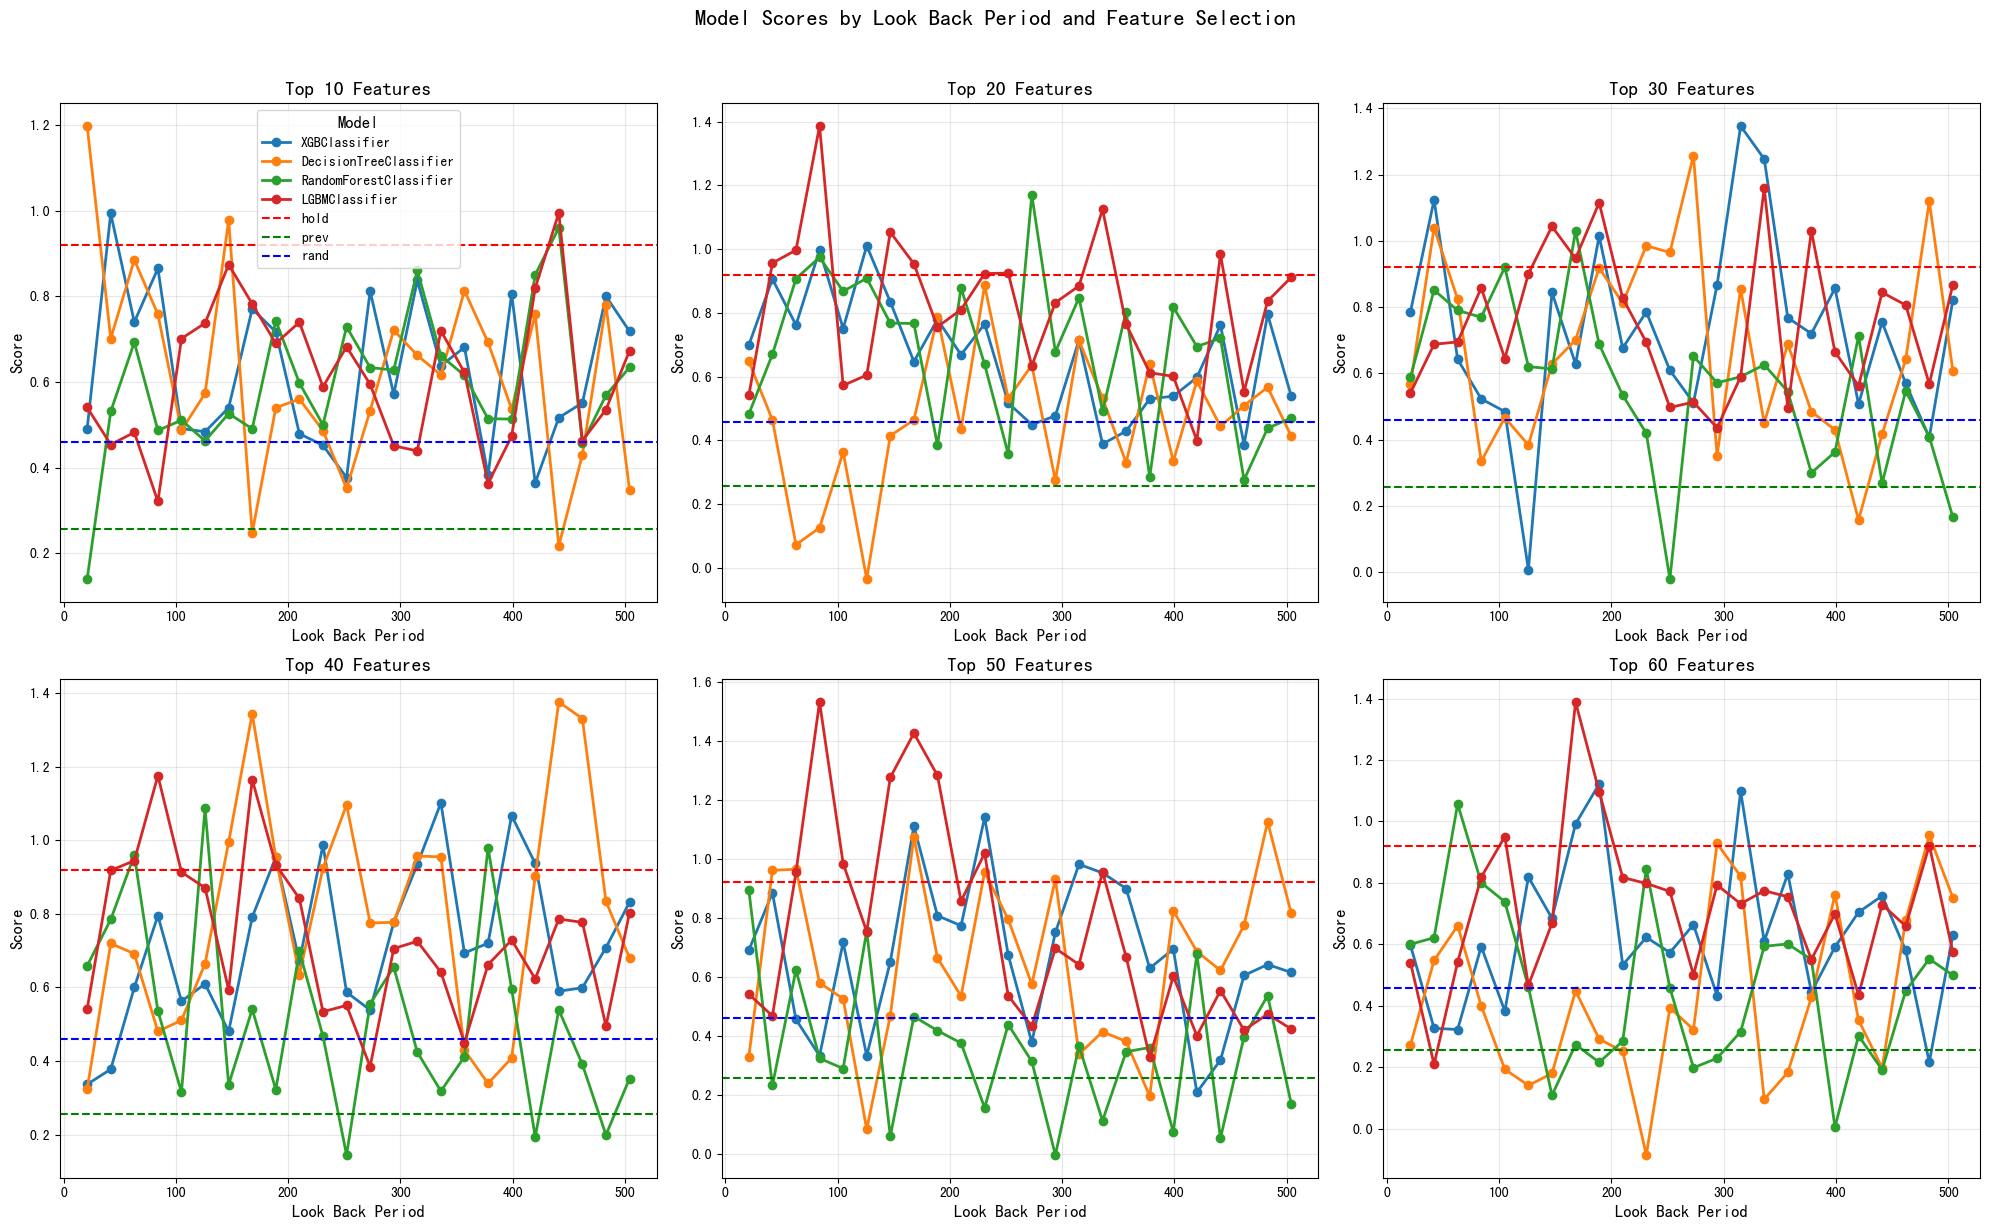

In [5]:
"""
构造特征后，模型平均表现明显优于随机策略，部分模型平均表现接近持有策略
"""

windows = [126]

opt = Optimizer(
    dataset=data,
    primitives=[
        enhance.RollingMin(windows),
        enhance.RollingMax(windows),
        enhance.RollingMean(windows),
        enhance.RollingStd(windows),
        enhance.RollingCountTrue(windows),
        enhance.RollingCountAboveMean(windows),
        enhance.RollingTrend(windows),
        enhance.RollingMaxConsecutiveTrue(windows),
        enhance.RollingMaxConsecutivePositives(windows),
        enhance.RollingNumSinceLastTrue(windows),
        enhance.Lag(),
        enhance.Diff(),
        enhance.PctChange(),
    ],
    drop_columns=to_drop + to_lag,
)
baseline = opt.baseline()
score_df, _, _ = get_importance_score(opt.x, opt.y)
opt.model_clz_list = [
    XGBClassifier,
    DecisionTreeClassifier,
    RandomForestClassifier,
    LGBMClassifier,
]
opt.look_back_list = [i * 21 for i in range(1, 25)]
opt.weight_func_list = [lambda x: x]

# 创建一个2x3的子图布局
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.subplots_adjust(hspace=0.4, wspace=0.3)  # 调整子图间距

for idx, i in enumerate(range(1, 7)):
    opt.pipeline = Pipeline([
        SelectColumns(score_df[:i * 10]["feature"]),
        MeanEncoder(),
    ])

    df = opt.score()

    # 确定当前子图的位置
    row = idx // 3  # 行索引
    col = idx % 3  # 列索引
    ax = axes[row, col]

    # 获取所有唯一的model
    models = df['model'].unique()

    # 为每个model绘制一条折线
    for model in models:
        # 提取该model的数据
        model_data = df[df['model'] == model]

        # 按look_back排序（如果需要）
        model_data = model_data.sort_values('look_back')

        # 绘制折线
        ax.plot(model_data['look_back'], model_data['score'], marker='o', label=model, linewidth=2)

    # 添加基准线
    ax.axhline(baseline["hold"], color='r', linestyle='--', label='hold')
    ax.axhline(baseline["prev"], color='g', linestyle='--', label='prev')
    ax.axhline(baseline["rand"], color='b', linestyle='--', label='rand')

    # 添加标题和标签
    ax.set_title(f'Top {i * 10} Features', fontsize=14)
    ax.set_xlabel('Look Back Period', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)

    # 添加图例（只在第一张图显示完整的图例，避免重复）
    if idx == 0:
        ax.legend(title='Model', title_fontsize=12, fontsize=10)
    else:
        # 可以只显示模型图例或省略图例
        # ax.legend(['models...'], title='Model', title_fontsize=12, fontsize=10)
        pass

    # 添加网格
    ax.grid(True, alpha=0.3)

# 为整个图形添加总标题
fig.suptitle('Model Scores by Look Back Period and Feature Selection', fontsize=16, y=1.02)

# 显示图形
plt.tight_layout()
plt.show()

In [11]:
#查看某一组合下模型在不同测试区间的表现

opt.report_one(
    model_clz=LGBMClassifier,
    look_back=84,
    weight_func=lambda x: x,
    pipeline=Pipeline([
        SelectColumns(score_df[:40]["feature"]),
        MeanEncoder(),
    ])
)

,sharpe,hold_sharpe,prev_sharpe,rand_sharpe
5274:5400,0.149139,3.403157,0.342322,0.882471
5148:5274,0.059702,-0.903425,-1.389761,-0.421477
5022:5148,0.454350,1.783775,0.378242,0.993432
4896:5022,3.602796,2.858746,1.560802,0.869755
4770:4896,0.216034,-0.000431,1.121110,0.277224
4644:4770,2.727452,1.030584,-0.088293,0.755010
4518:4644,-0.175492,-1.356372,-1.224475,-0.682250
4392:4518,0.877208,-0.292491,-0.063249,0.028871
4266:4392,2.667245,1.758864,1.669427,1.010932
avg,1.175382,0.920268,0.256236,0.412663


### 优化方向

1. 目标是让模型的表现明显优于hold策略，并且具有稳定性。稳定性的表现

    - 不同模型的表现都比较好
    - 不同look_back窗口下的评分突变小
    - 不同特征截断值下的评分突变小

2. 可以优化的内容

    - 预测target: 使用bool型还是数值型、使用当日值还是趋势值
    - 特征工程: 构造哪些变量
    - 模型选择: 表格模型还是时序预测模型
    - weight_func: 如何将模型预测值转为权重